# CycleGAN Patchwise Inference
Dieses Notebook zeigt, wie ein trainierter CycleGAN-Generator große Bilder 
per Kachelgitter verarbeitet. Patches werden einzeln konvertiert und anschließend 
durch einfaches Mittelwerten wieder zusammengesetzt. Passe die Parameter unten 
(Checkpoint, Bildpfad, Patchgröße/Stride) an deinen Anwendungsfall an.


In [41]:

import math
from pathlib import Path

import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TF
from monai.inferers import SlidingWindowInferer

import os

os.chdir("/srv/store/docker-users/thesis/khajuria/day2night")
print("Current working directory:", os.getcwd())


from src.utils.common import load_cfg, resolve_encoder_checkpoint
from src.models.cyclegan import CycleGANGenerator
from src.apply_cyclegan import build_inference_transform


Current working directory: /srv/store/docker-users/thesis/khajuria/day2night


In [ ]:

# --- Benutzer-Parameter ---
CONFIG_PATH = "configs/cyclegan.yaml"
CHECKPOINT_PATH = None  # "experiments/cyclegan_day2night_20251110_172804/epoch_0200.pt" #None  # Optional: expliziter Pfad zu epoch_XXXX.pt
DIRECTION = "day2night"  # oder "night2day"
INPUT_IMAGE = "data/night2day/night_to_day/testA/1abbe94b-c840d3b2.jpg"
INPUT_RESIZE = None #(640, 360)  # None = Originalgröße behalten, oder (Breite, Höhe)
ADAPTIVE_STRIDE = True  # reduziert Überlappung bei kleinen Bildern
TILE_SIZE = None  # None = nutzt die Center-Crop-Größe aus cfg.transforms
TILE_STRIDE = None  # None = 75% von TILE_SIZE
USE_MONAI = True  # True = SlidingWindowInferer verwenden
MONAI_SW_BATCH = 4
MONAI_OVERLAP = None  # None = automatisch aus Stride/Tile berechnen
SAVE_RESULT = True
OUTPUT_DIR = "results/cyclegan_patches"
OUTPUT_SUFFIX = "patched"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [43]:

def find_checkpoint(cfg, explicit=None):
    if explicit:
        path = Path(explicit)
        if not path.is_file():
            raise FileNotFoundError(f"Checkpoint nicht gefunden: {path}")
        return path
    exp_root = Path(cfg["logging"]["out_dir"])
    pattern = sorted(exp_root.glob(f"{cfg['exp_name']}_*/epoch_*.pt"))
    if not pattern:
        raise RuntimeError(f"Keine Checkpoints unter {exp_root} gefunden.")
    return pattern[-1]


def build_generator(cfg, device):
    gen_cfg = cfg["model"]["generator"]
    encoder_ckpt = resolve_encoder_checkpoint(
        gen_cfg.get("encoder_checkpoint"),
        experiments_root=cfg["logging"].get("out_dir", "experiments"),
        default_run_prefix=gen_cfg.get("encoder_run_prefix", "seg"),
        filename=gen_cfg.get("encoder_filename", "encoder_GE.pth"),
    )
    model = CycleGANGenerator(
        in_channels=gen_cfg.get("in_channels", 3),
        out_channels=gen_cfg.get("out_channels", 3),
        base_channels=gen_cfg.get("base_channels", 64),
        n_res_blocks=gen_cfg.get("n_res_blocks", 9),
        use_skip=gen_cfg.get("use_skip", True),
        encoder_checkpoint=encoder_ckpt,
        freeze_encoder=gen_cfg.get("freeze_encoder", False),
        decoder_res_blocks=gen_cfg.get("decoder_res_blocks", 3),
    ).to(device)
    return model


def prepare_image_tensor(pil_image, transform, tile_size, device):
    tensor = transform(pil_image).unsqueeze(0).to(device)
    _, _, h, w = tensor.shape
    pad_h = max(0, tile_size - h)
    pad_w = max(0, tile_size - w)
    if pad_h > 0 or pad_w > 0:
        tensor = F.pad(tensor, (0, pad_w, 0, pad_h), mode="reflect")
    return tensor, h, w


def sliding_window_manual(generator, pil_image, transform, tile_size=256, stride=128, device=torch.device("cpu")):
    base, orig_h, orig_w = prepare_image_tensor(pil_image, transform, tile_size, device)
    base = base.squeeze(0)
    c, h, w = base.shape

    def make_coords(length):
        if length <= tile_size:
            return [0]
        coords = list(range(0, length - tile_size + 1, stride))
        if coords[-1] != length - tile_size:
            coords.append(length - tile_size)
        return coords

    ys = make_coords(h)
    xs = make_coords(w)
    accum = torch.zeros((c, h, w), device=device)
    weight = torch.zeros((1, h, w), device=device)
    patch_weight = torch.ones((1, tile_size, tile_size), device=device)

    generator.eval()
    with torch.inference_mode():
        for y in ys:
            for x in xs:
                patch = base[:, y:y+tile_size, x:x+tile_size].unsqueeze(0)
                out = generator(patch)
                accum[:, y:y+tile_size, x:x+tile_size] += out.squeeze(0) * patch_weight
                weight[:, y:y+tile_size, x:x+tile_size] += patch_weight

    weight = weight.clamp_min(1e-6)
    result = accum / weight
    return result[:, :orig_h, :orig_w]


def sliding_window_monai(generator, pil_image, transform, tile_size=256, stride=128, device=torch.device("cpu"), sw_batch=4, overlap=None):
    tensor, orig_h, orig_w = prepare_image_tensor(pil_image, transform, tile_size, device)
    if overlap is None:
        overlap = 1.0 - min(1.0, stride / float(tile_size))
        overlap = max(0.0, min(0.9, overlap))
    inferer = SlidingWindowInferer(
        roi_size=(tile_size, tile_size),
        sw_batch_size=sw_batch,
        overlap=overlap,
        padding_mode="reflect",
        mode="gaussian",
    )
    generator.eval()
    with torch.inference_mode():
        output = inferer(tensor, generator)
    return output.squeeze(0)[:, :orig_h, :orig_w]


def tensor_to_image(tensor):
    tensor = tensor.detach().clamp(-1, 1)
    tensor = (tensor + 1) / 2
    return TF.to_pil_image(tensor.cpu())


In [44]:

cfg = load_cfg(CONFIG_PATH)
tf_cfg = cfg.get("transforms", {})
inference_transform = build_inference_transform(cfg)

crop_size = tf_cfg.get("center_crop") or tf_cfg.get("random_crop")
default_tile = crop_size or tf_cfg.get("resize")
tile_size = TILE_SIZE or default_tile or 256
if not isinstance(tile_size, int):
    tile_size = int(tile_size)
tile_stride = TILE_STRIDE or int(tile_size * 0.75)

TILE_SIZE = tile_size
TILE_STRIDE = tile_stride
print(f"Transformations-Pipeline: resize={tf_cfg.get('resize')} -> center_crop={tf_cfg.get('center_crop')}")
print(f"Tile-Konfiguration: size={TILE_SIZE}, stride={TILE_STRIDE}")

checkpoint = find_checkpoint(cfg, CHECKPOINT_PATH)
print(f"Nutze Checkpoint: {checkpoint}")
key = "G" if DIRECTION == "day2night" else "F"
generator = build_generator(cfg, DEVICE)
generator.load_state_dict(torch.load(checkpoint, map_location="cpu", weights_only=True)[key])
generator.to(DEVICE)
generator.eval()
print(f"Generator für {DIRECTION} ist geladen und bereit.")


Nutze Checkpoint: experiments/cyclegan_day2night_20251125_012836/epoch_0200.pt
Generator für day2night ist geladen und bereit.


Gespeichert unter results/cyclegan_patches/day2night/1abbe94b-c840d3b2_patched.png


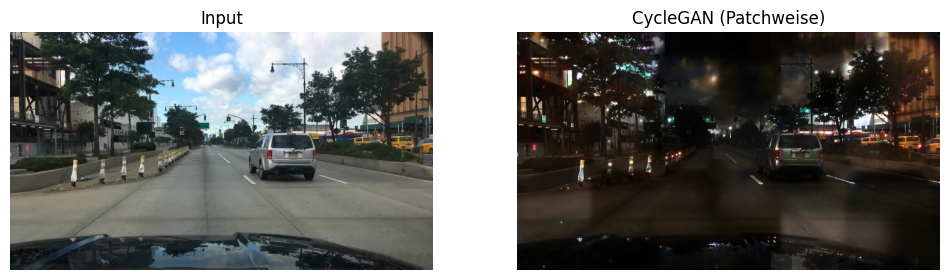

In [45]:

input_path = Path(INPUT_IMAGE)
if not input_path.is_file():
    raise FileNotFoundError(f"Eingangsbild nicht gefunden: {input_path}")
original = Image.open(input_path).convert("RGB")
processed_input = original
resize_note = None
if INPUT_RESIZE:
    if not isinstance(INPUT_RESIZE, (tuple, list)) or len(INPUT_RESIZE) != 2:
        raise ValueError("INPUT_RESIZE muss (Breite, Höhe) sein oder None")
    target_w, target_h = int(INPUT_RESIZE[0]), int(INPUT_RESIZE[1])
    if target_w <= 0 or target_h <= 0:
        raise ValueError("Breite/Höhe müssen positiv sein")
    processed_input = original.resize((target_w, target_h), Image.BICUBIC)
    resize_note = f"Input manuell auf {target_w}x{target_h} gesetzt."
if resize_note:
    print(resize_note + f" Original: {original.width}x{original.height}.")

fits_single_tile = processed_input.width <= TILE_SIZE and processed_input.height <= TILE_SIZE
effective_stride = TILE_STRIDE
adaptive_note = None
if ADAPTIVE_STRIDE and not fits_single_tile:
    max_dim = max(processed_input.width, processed_input.height)
    if max_dim <= TILE_SIZE * 1.5:
        effective_stride = TILE_SIZE
        adaptive_note = f"Adaptive Stride: nutze {effective_stride}px (kein overlap) für kompaktere Bilder."
    else:
        effective_stride = TILE_STRIDE
else:
    effective_stride = TILE_STRIDE
if adaptive_note:
    print(adaptive_note)

if fits_single_tile:
    print("Bild passt in eine einzelne Kachel -> direkter Durchlauf ohne Sliding Window.")
    with torch.inference_mode():
        tensor = inference_transform(processed_input).unsqueeze(0).to(DEVICE)
        output_tensor = generator(tensor).squeeze(0)
else:
    if USE_MONAI:
        output_tensor = sliding_window_monai(
            generator,
            processed_input,
            inference_transform,
            tile_size=TILE_SIZE,
            stride=effective_stride,
            device=DEVICE,
            sw_batch=MONAI_SW_BATCH,
            overlap=MONAI_OVERLAP,
        )
    else:
        output_tensor = sliding_window_manual(
            generator,
            processed_input,
            inference_transform,
            tile_size=TILE_SIZE,
            stride=effective_stride,
            device=DEVICE,
        )

result_img = tensor_to_image(output_tensor)

if SAVE_RESULT:
    out_dir = Path(OUTPUT_DIR) / DIRECTION
    out_dir.mkdir(parents=True, exist_ok=True)
    suffix = f"_{OUTPUT_SUFFIX}" if OUTPUT_SUFFIX else ""
    out_path = out_dir / f"{input_path.stem}{suffix}.png"
    result_img.save(out_path)
    print(f"Gespeichert unter {out_path}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(processed_input)
if resize_note:
    title = "Input (manuell resized)"
else:
    title = "Input"
plt.title(title)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_img)
plt.title("CycleGAN (Patchweise)" if not fits_single_tile else "CycleGAN (Single Pass)")
plt.axis("off")
plt.show()
